In [3]:
#  Install required libraries

!pip install -q datasets transformers accelerate evaluate scikit-learn matplotlib seaborn huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


This installs the main libraries we need:

datasets - to download Amazon reviews,
transformers - to use DistilBERT,
accelerate - helps training run properly on GPU,
evaluate - metrics like accuracy/F1,
huggingface_hub - to upload your trained model to Hugging Face

In [4]:
# Imports + GPU check

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU found. Go to Runtime > Change runtime type > T4 GPU")

GPU available: False
No GPU found. Go to Runtime > Change runtime type > T4 GPU


In [5]:
# Load dataset from HuggingFace

dataset = load_dataset("amazon_polarity")

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

In [6]:
# Take a smaller sample (200K total)

train_data = dataset["train"].shuffle(seed=42).select(range(180000))
test_data = dataset["test"].shuffle(seed=42).select(range(20000))

print(train_data, test_data)

Dataset({
    features: ['label', 'title', 'content'],
    num_rows: 180000
}) Dataset({
    features: ['label', 'title', 'content'],
    num_rows: 20000
})


In [7]:
# Convert to pandas for quick inspection

df = train_data.to_pandas()

df.head()

,label,title,content
0,0,Anyone who likes this better than the Pekinpah...,All the pretty people in this film. Even the R...
1,0,Author seems mentally unstable,I know that Tom Robbins has a loyal following ...
2,1,Spaetzle Noodles,This type of spaetzle maker is easier to manuv...
3,1,Cool product until the cats lost it . . . .,My cats seemed to be amused to work for their ...
4,1,Works as expected,I've had no problems running this with my Dell...


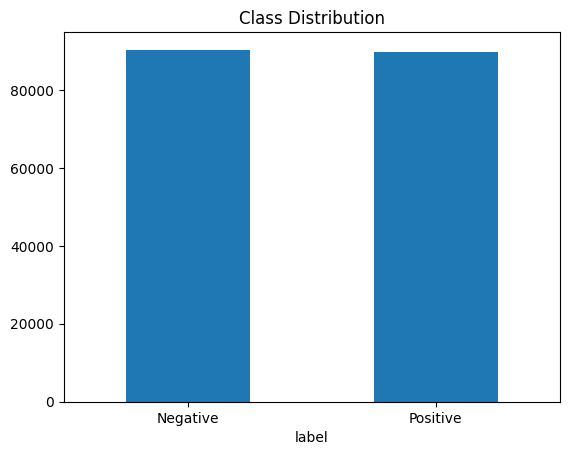

In [8]:
# Class distribution

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xticks([0,1], ['Negative', 'Positive'], rotation=0)
plt.show()

In [9]:
# Show few examples

print("Positive example:\n", df[df['label']==1]['content'].iloc[0])
print("\nNegative example:\n", df[df['label']==0]['content'].iloc[0])

Positive example:
 This type of spaetzle maker is easier to manuveur than the old press kind and much easier on the hands. The difference is that this new spaetzle maker makes smaller noodles than the old. It is great for us elderly that don't have much strength left.

Negative example:
 All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciting and suspenseful than anything in this re-make.


In [10]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)  # remove special characters
    return text

# Apply cleaning
train_data = train_data.map(lambda x: {"content": clean_text(x["content"])})
test_data = test_data.map(lambda x: {"content": clean_text(x["content"])})

Map:   0%|          | 0/180000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["content"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_data = train_data.map(tokenize_function, batched=True)
test_data = test_data.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/180000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

In [12]:
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [1]:
from transformers import EarlyStoppingCallback

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [15]:
print(len(train_data), len(test_data))

180000 20000


In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.197182,0.195976,0.935550,0.942814,0.927881,0.935288


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.197182,0.195976,0.935550,0.942814,0.927881,0.935288
2,0.125458,0.213762,0.938400,0.938116,0.939237,0.938676


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=22500, training_loss=0.17697010752360026, metrics={'train_runtime': 4502.5498, 'train_samples_per_second': 79.955, 'train_steps_per_second': 4.997, 'total_flos': 1.192206587904e+16, 'train_loss': 0.17697010752360026, 'epoch': 2.0})

In [17]:
eval_results = trainer.evaluate()
eval_results

{'eval_loss': 0.21376244723796844,
 'eval_accuracy': 0.9384,
 'eval_precision': 0.9381156103870262,
 'eval_recall': 0.9392369757944018,
 'eval_f1': 0.9386759581881533,
 'eval_runtime': 86.6057,
 'eval_samples_per_second': 230.932,
 'eval_steps_per_second': 14.433,
 'epoch': 2.0}

In [18]:
predictions_output = trainer.predict(test_data)

logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=1)

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94      9961
    Positive       0.94      0.94      0.94     10039

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



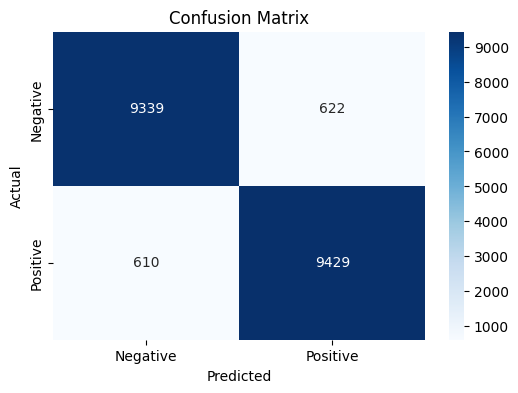

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

probs = softmax(logits, axis=1)
positive_probs = probs[:, 1]

roc_auc = roc_auc_score(y_true, positive_probs)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9828732945028095


In [22]:
save_path = "./sentiment_distilbert_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./sentiment_distilbert_model


In [23]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "text-classification",
    model=save_path,
    tokenizer=save_path,
    device=0
)

sample_reviews = [
    "This product is amazing. I loved the quality.",
    "Terrible product. Waste of money.",
    "The item is okay, not great but not bad either."
]

for review in sample_reviews:
    print(review)
    print(sentiment_pipeline(review))
    print()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

This product is amazing. I loved the quality.
[{'label': 'LABEL_1', 'score': 0.9974258542060852}]

Terrible product. Waste of money.
[{'label': 'LABEL_0', 'score': 0.9996254444122314}]

The item is okay, not great but not bad either.
[{'label': 'LABEL_1', 'score': 0.8172932267189026}]



In [24]:
from huggingface_hub import notebook_login
notebook_login()

In [25]:
model.push_to_hub("amazon-sentiment-distilbert")
tokenizer.push_to_hub("amazon-sentiment-distilbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...jy2kqlh/model.safetensors:   0%|          |  575kB /  268MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/anjanajolly/amazon-sentiment-distilbert/commit/c9a869754dd083e520ea8b6225b551a77d07b7ef', commit_message='Upload tokenizer', commit_description='', oid='c9a869754dd083e520ea8b6225b551a77d07b7ef', pr_url=None, repo_url=RepoUrl('https://huggingface.co/anjanajolly/amazon-sentiment-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='anjanajolly/amazon-sentiment-distilbert'), pr_revision=None, pr_num=None)